--- TEXT OUTPUT ---
Algorithm            Path Found  Total Cost
      BFS      S -> A -> C -> G           9
      DFS S -> A -> B -> C -> G           8
       A* S -> A -> B -> C -> G           8

Showing Pandas Visualization... (Check popup window)


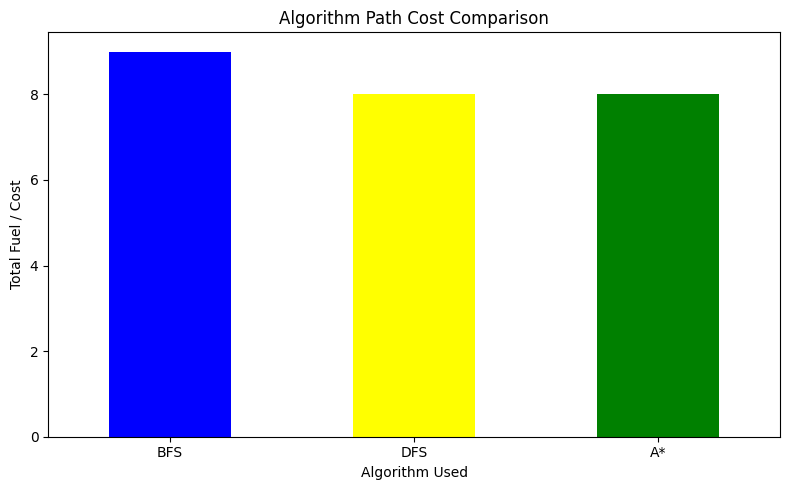

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
import heapq
# the actual graph diff
# Define dataset
edges_data = [
    {'from': 'S', 'to': 'A', 'cost': 1},
    {'from': 'S', 'to': 'B', 'cost': 4},
    {'from': 'A', 'to': 'B', 'cost': 2},
    {'from': 'A', 'to': 'C', 'cost': 5},
    {'from': 'B', 'to': 'C', 'cost': 2},
    {'from': 'C', 'to': 'G', 'cost': 3}
]

heuristics_data = [
    {'node': 'S', 'h': 7},
    {'node': 'A', 'h': 6},
    {'node': 'B', 'h': 4},
    {'node': 'C', 'h': 2},
    {'node': 'G', 'h': 0}
]

# Load strictly into Pandas
df_edges = pd.DataFrame(edges_data)
df_heuristics = pd.DataFrame(heuristics_data)

def bfs(df_edges, start, goal):
    queue = deque([([start], 0)])
    visited = set([start])
    
    while queue:
        path, current_cost = queue.popleft()
        node = path[-1]
        
        if node == goal:
            return path, current_cost
            
        # Querying Pandas DataFrame directly instead of a graph dictionary
        neighbors = df_edges[df_edges['from'] == node]
        for _, row in neighbors.iterrows():
            neighbor = row['to']
            cost = row['cost']
            
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((path + [neighbor], current_cost + cost))
    return [], 0

def dfs(df_edges, start, goal):
    stack = [([start], 0)]
    visited = set()
    
    while stack:
        path, current_cost = stack.pop()
        node = path[-1]
        
        if node == goal:
            return path, current_cost
            
        if node not in visited:
            visited.add(node)
            neighbors = df_edges[df_edges['from'] == node]
            
            # Reversing to maintain standard left-to-right exploration
            for _, row in neighbors.iloc[::-1].iterrows():
                neighbor = row['to']
                cost = row['cost']
                if neighbor not in visited:
                    stack.append((path + [neighbor], current_cost + cost))
    return [], 0

def a_star(df_edges, df_heuristics, start, goal):
    start_h = df_heuristics[df_heuristics['node'] == start]['h'].values[0]
    pq = [(start_h, 0, start, [start])]
    visited = set()
    
    while pq:
        f, g, node, path = heapq.heappop(pq)
        
        if node == goal:
            return path, g
            
        if node in visited:
            continue
            
        visited.add(node)
        
        neighbors = df_edges[df_edges['from'] == node]
        for _, row in neighbors.iterrows():
            neighbor = row['to']
            cost = row['cost']
            
            if neighbor not in visited:
                new_g = g + cost
                neighbor_h = df_heuristics[df_heuristics['node'] == neighbor]['h'].values[0]
                new_f = new_g + neighbor_h
                heapq.heappush(pq, (new_f, new_g, neighbor, path + [neighbor]))
    return [], 0

start_node = 'S'
goal_node = 'G'

bfs_path, bfs_cost = bfs(df_edges, start_node, goal_node)
dfs_path, dfs_cost = dfs(df_edges, start_node, goal_node)
astar_path, astar_cost = a_star(df_edges, df_heuristics, start_node, goal_node)

results_data = [
    {'Algorithm': 'BFS', 'Path Found': " -> ".join(bfs_path), 'Total Cost': bfs_cost},
    {'Algorithm': 'DFS', 'Path Found': " -> ".join(dfs_path), 'Total Cost': dfs_cost},
    {'Algorithm': 'A*', 'Path Found': " -> ".join(astar_path), 'Total Cost': astar_cost}
]

df_results = pd.DataFrame(results_data)

print("--- TEXT OUTPUT ---")
print(df_results.to_string(index=False))


df_results.plot(
    x='Algorithm', 
    y='Total Cost', 
    kind='bar', 
    color=['blue', 'yellow', 'green'], 
    legend=False,
    figsize=(8, 5)
)

plt.title('Algorithm Path Cost Comparison')
plt.ylabel('Total Fuel / Cost')
plt.xlabel('Algorithm Used')
plt.xticks(rotation=0)
plt.tight_layout()

print("\nShowing Pandas Visualization... (Check popup window)")
plt.show()

In [4]:
df_edges = pd.DataFrame(edges_data)
df_heuristics = pd.DataFrame(heuristics_data)


print(df_edges)
print(df_heuristics)

  from to  cost
0    S  A     1
1    S  B     4
2    A  B     2
3    A  C     5
4    B  C     2
5    C  G     3
  node  h
0    S  7
1    A  6
2    B  4
3    C  2
4    G  0


## BEST FIRST SEARCH

In [1]:
import heapq

def greedy_best_first(graph, heuristics, start, goal):
    # Priority Queue stores: (heuristic_value, path)
    pq = [(heuristics[start], [start])]
    visited = set()
    
    print("\nGreedy Best-First Traversal Steps:")
    while pq:
        h_val, path = heapq.heappop(pq)
        node = path[-1]
        print(f"-> Chose Node {node} because it has the lowest heuristic ({h_val})")
        
        if node == goal:
            return f"\nSUCCESS: Greedy Path is {' -> '.join(path)}"
            
        visited.add(node)
        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                heapq.heappush(pq, (heuristics[neighbor], path + [neighbor]))

graph_informed = {'S': ['A', 'B'], 'A': ['C', 'G'], 'B': ['G'], 'C': [], 'G': []}
# Heuristics: G is 0 because it IS the goal.
heuristics = {'S': 10, 'A': 4, 'B': 2, 'C': 6, 'G': 0} 

print(greedy_best_first(graph_informed, heuristics, 'S', 'G'))


Greedy Best-First Traversal Steps:
-> Chose Node S because it has the lowest heuristic (10)
-> Chose Node B because it has the lowest heuristic (2)
-> Chose Node G because it has the lowest heuristic (0)

SUCCESS: Greedy Path is S -> B -> G
